In [456]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [457]:
df = pd.read_csv(r"C:\Users\Acer\Music\python-20260412T115804Z-3-001\eda_step_1\model\nlp\text.csv")

In [458]:
df

,Unnamed: 0,text,label
0,0,i just feel really helpless and heavy hearted,4
1,1,ive enjoyed being able to slouch about relax a...,0
2,2,i gave up my internship with the dmrg and am f...,4
3,3,i dont know i feel so lost,0
4,4,i am a kindergarten teacher and i am thoroughl...,4
...,...,...,...
416804,416804,i feel like telling these horny devils to find...,2
416805,416805,i began to realize that when i was feeling agi...,3
416806,416806,i feel very curious be why previous early dawn...,5
416807,416807,i feel that becuase of the tyranical nature of...,3


In [459]:
df["label"].unique()

array([4, 0, 2, 1, 5, 3])

In [460]:
df.isnull().sum()

Unnamed: 0    0
text          0
label         0
dtype: int64

In [461]:
df["text"] = df["text"].str.lower()

In [462]:
import string
def remove(text):
    return text.translate(str.maketrans("","",string.punctuation))

In [463]:
df["text"]=df["text"].apply(remove)

In [464]:
df

,Unnamed: 0,text,label
0,0,i just feel really helpless and heavy hearted,4
1,1,ive enjoyed being able to slouch about relax a...,0
2,2,i gave up my internship with the dmrg and am f...,4
3,3,i dont know i feel so lost,0
4,4,i am a kindergarten teacher and i am thoroughl...,4
...,...,...,...
416804,416804,i feel like telling these horny devils to find...,2
416805,416805,i began to realize that when i was feeling agi...,3
416806,416806,i feel very curious be why previous early dawn...,5
416807,416807,i feel that becuase of the tyranical nature of...,3


In [465]:
def numbers(text):
    new=""
    for i in text:
        if not i.isdigit():
            new=new+i
    return new

In [466]:
df["text"]=df["text"].apply(numbers)

In [467]:
import re
def email(text):
    return re.sub(r'https?://\S+|www\.\S','',text) #re.sub(pattern, replacement, string) 

In [468]:
def tag(text):
     return re.sub(r'<.*?>','',text)

In [469]:
import emoji

def remove_emoji(text):
    return emoji.replace_emoji(text, replace='')

In [470]:
def sepcial(text):
    return re(r'[^a-zA-Z\s]','',text)

In [471]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download("stopwords")
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [472]:
stop_words=set(stopwords.words("english"))

In [473]:
def stop(text):
    words=word_tokenize(text)
    new=[]
    for i in words:
       if i not in stop_words:
            new.append(i)
    return ' '.join(new)

In [474]:
df["text"]=df["text"].apply(stop)

In [475]:
df.loc[1]['text']

'ive enjoyed able slouch relax unwind frankly needed last weeks around end uni expo lately started find feeling bit listless never really good thing'

In [476]:
X=df["text"]
y=df["label"]

In [477]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    stop_words='english'
)
X=tfidf.fit_transform(X)

In [478]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4410745 stored elements and shape (416809, 50000)>

In [479]:


X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [480]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model=LogisticRegression(max_iter=1000,class_weight="balanced")
model.fit(X_train,y_train)
pred=model.predict(X_test)
print(accuracy_score(y_test,pred))

0.9091672464672153


In [481]:
import joblib

joblib.dump(model, "emotion_model.pkl")
joblib.dump(tfidf, "tfidf.pkl")

['tfidf.pkl']

In [482]:
df["label"].value_counts()

label
1    141067
0    121187
3     57317
4     47712
2     34554
5     14972
Name: count, dtype: int64

In [483]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95     24201
           1       0.97      0.89      0.93     28164
           2       0.74      0.96      0.83      6929
           3       0.90      0.94      0.92     11441
           4       0.87      0.86      0.86      9594
           5       0.68      0.90      0.77      3033

    accuracy                           0.91     83362
   macro avg       0.85      0.91      0.88     83362
weighted avg       0.92      0.91      0.91     83362



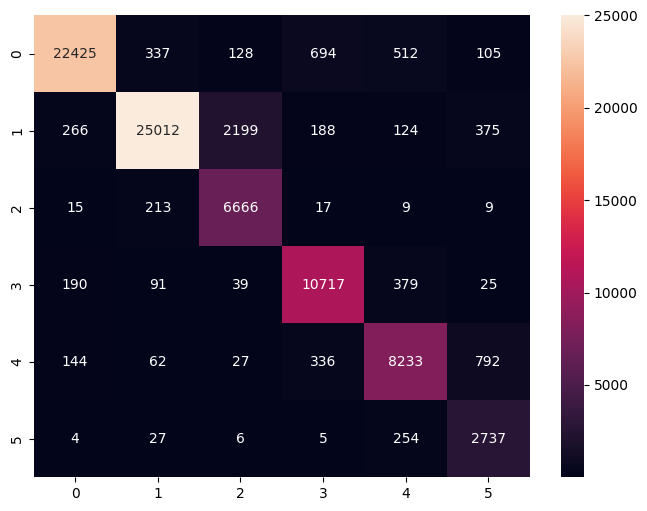

In [484]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.show()